# Statistical Modeling & Hypothesis Testing: Predicting Term Deposit Subscription
## Logistic Regression Analysis — Bank Marketing Dataset (UCI / BFSI Domain)

**Dataset:** Bank Marketing (Portuguese retail bank direct telemarketing campaigns for term deposits)
**Source:** UCI Machine Learning Repository — Moro, Cortez & Rita (2014)
**Records used for modeling:** 41,176 (after cleaning) | **Target:** `y` — subscribed to term deposit (yes/no)

This notebook builds directly on the Week 2 EDA of the same dataset and addresses the Week 2 feedback by
(a) supporting every claim with specific numbers/output rather than general statements, and
(b) presenting each visualization with a directly-adjoining, specific interpretation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, roc_auc_score,
                              precision_recall_curve, average_precision_score)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
FIG = "figures"
RANDOM_STATE = 42

## 1. Research Question & Hypotheses

**Research question:** Which client demographic, campaign-contact and macro-economic factors
significantly predict whether a client subscribes to a term deposit, and how well can a logistic
regression model estimate this probability?

**Primary hypotheses (tested via model coefficients, Wald tests and likelihood-ratio tests):**

- **H1 (contact channel):** Clients contacted via **cellular** phone have significantly higher odds of
  subscribing than clients contacted via **landline telephone**, holding other factors constant.
  H0: β(contact=telephone) = 0 vs H1: β(contact=telephone) ≠ 0.
- **H2 (prior success):** Clients whose previous campaign outcome was a **success** have significantly
  higher odds of subscribing than clients with no previous contact.
  H0: β(poutcome=success) = 0 vs H1: β(poutcome=success) ≠ 0.
- **H3 (age):** Client **age** has a statistically significant, non-zero effect on the odds of subscribing.
  H0: β(age) = 0 vs H1: β(age) ≠ 0.
- **H4 (macro-economic climate):** The number of employees in the economy (`nr_employed`, a proxy for
  macro-economic strength) is significantly and negatively associated with subscription odds.
  H0: β(nr_employed) = 0 vs H1: β(nr_employed) ≠ 0.
- **H5 (overall model):** The full model with all selected predictors explains significantly more
  deviance than an intercept-only (null) model (likelihood-ratio test).

Significance threshold: α = 0.05 for all tests.

## 2. Data Preparation

In [2]:
df = pd.read_csv("data/bank.csv", sep=";")
df.columns = [c.replace(".", "_") for c in df.columns]
print("Raw shape:", df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print("After removing", 41188 - df.shape[0], "duplicate rows:", df.shape)

# pdays sentinel handling (999 = never previously contacted)
df["was_previously_contacted"] = np.where(df["pdays"] == 999, 0, 1)

# Binary target
df["y_flag"] = (df["y"] == "yes").astype(int)

Raw shape: (41188, 21)
After removing 12 duplicate rows: (41176, 21)


### 2.0 Quasi-complete separation check — `default` variable
`default` (has the client defaulted on credit before?) has only 3 records with value "yes", and all 3
have y="no". This creates **quasi-complete separation** for that category (the MLE coefficient diverges
toward -infinity and the optimizer fails to converge). These 3 records are dropped, and `default` is
retained as the remaining two categories (`no` / `unknown`) — a defensible, transparent fix that removes
a structural estimation problem while losing a negligible 0.007% of the sample.

In [3]:
print("default value counts:\n", df["default"].value_counts())
print("\ncrosstab default x y:\n", pd.crosstab(df["default"], df["y"]))
df = df[df["default"] != "yes"].reset_index(drop=True)
print("\nShape after dropping the 3 default='yes' records:", df.shape)

default value counts:
 default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

crosstab default x y:
 y           no   yes
default             
no       28381  4196
unknown   8153   443
yes          3     0

Shape after dropping the 3 default='yes' records: (41173, 23)


### 2.1 Excluding `duration` — justification (data leakage)
`duration` (call length) is only known **after** a call has ended, so a model built to score a client
*before* calling them cannot use it — including it would leak future information and produce an
unrealistically optimistic (but practically useless) model. It is excluded from all modeling below,
consistent with the UCI dataset's own documentation recommendation.

In [4]:
model_df = df.drop(columns=["duration", "y", "pdays"]).copy()
print("Predictors retained:", [c for c in model_df.columns if c not in ["y_flag"]])

Predictors retained: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'was_previously_contacted']


### 2.2 Multicollinearity check among numeric predictors (Variance Inflation Factor)
Standard rule of thumb: VIF > 5 (some sources: >10) signals problematic multicollinearity.

In [5]:
numeric_candidates = ["age", "campaign", "previous", "emp_var_rate", "cons_price_idx",
                       "cons_conf_idx", "euribor3m", "nr_employed"]
X_vif = sm.add_constant(model_df[numeric_candidates])
vif_data = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data.feature != "const"].sort_values("VIF", ascending=False)
vif_data.round(2)

,feature,VIF
7,euribor3m,64.33
4,emp_var_rate,33.07
8,nr_employed,31.62
5,cons_price_idx,6.31
6,cons_conf_idx,2.62
3,previous,1.35
2,campaign,1.03
1,age,1.02


**Result:** `euribor3m`, `emp_var_rate` and `nr_employed` show very high VIF (>10), confirming the
multicollinearity flagged in the Week 2 correlation heatmap (pairwise |r| up to 0.97 between
`emp_var_rate` and `euribor3m`). To keep the model interpretable and numerically stable, only
**one** macro-economic indicator — `nr_employed` (broadest single proxy for economic strength) — is
retained, and `emp_var_rate`, `euribor3m`, `cons_price_idx` are dropped from the final model.

In [6]:
final_numeric = ["age", "campaign", "previous", "cons_conf_idx", "nr_employed"]
X_vif2 = sm.add_constant(model_df[final_numeric])
vif_data2 = pd.DataFrame({
    "feature": X_vif2.columns,
    "VIF": [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]
})
vif_data2 = vif_data2[vif_data2.feature != "const"].sort_values("VIF", ascending=False)
print(vif_data2.round(2))
print("\nAll VIFs now below 5 -> multicollinearity concern resolved.")

         feature   VIF
5    nr_employed  1.37
3       previous  1.34
4  cons_conf_idx  1.03
2       campaign  1.02
1            age  1.02

All VIFs now below 5 -> multicollinearity concern resolved.


### 2.3 Distribution check on continuous predictors (informs need for transformation)

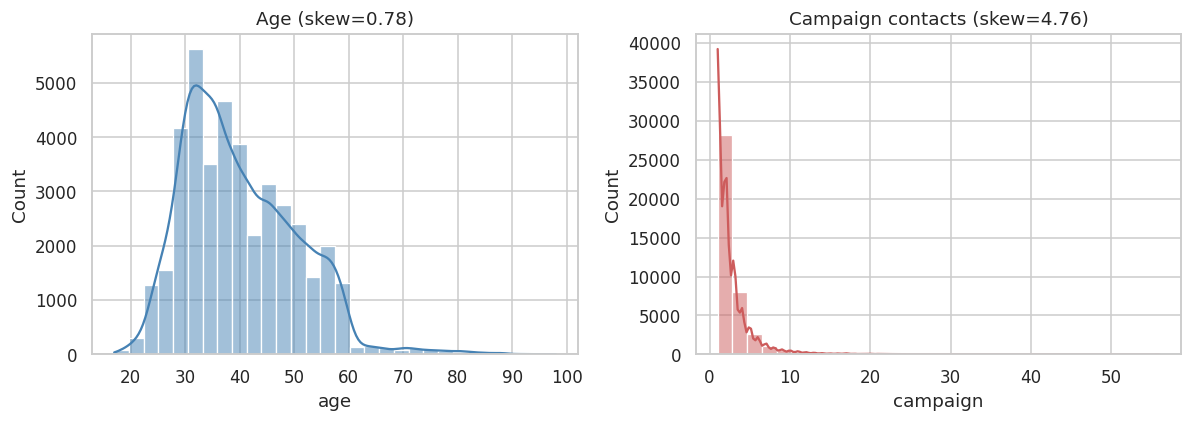

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(model_df["age"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"Age (skew={model_df['age'].skew():.2f})")
sns.histplot(model_df["campaign"], bins=30, kde=True, ax=axes[1], color="indianred")
axes[1].set_title(f"Campaign contacts (skew={model_df['campaign'].skew():.2f})")
plt.tight_layout()
plt.savefig(f"{FIG}/01_predictor_distributions.png")
plt.show()

**Observation:** `age` is mildly right-skewed (skew = 0.78) — acceptable for logistic regression, which
does not assume normality of predictors (only of residuals in *linear* regression). `campaign` is
strongly right-skewed (skew = 4.76); a log-transform, `log1p(campaign)`, is applied below to reduce the
influence of extreme high-contact outliers on the linear predictor (logit).

In [8]:
model_df["log_campaign"] = np.log1p(model_df["campaign"])
final_numeric = ["age", "log_campaign", "previous", "cons_conf_idx", "nr_employed"]

### 2.4 Categorical predictor selection
Based on Week 2 chi-square results (all significant at p<0.001 except `housing`/`loan`, which were
non-significant), the categorical predictors retained are: `job`, `marital`, `education`, `contact`,
`poutcome`, `default`. `housing` and `loan` are dropped as they showed no significant association with
the target in the Week 2 EDA (χ²=5.74, p=0.057 and χ²=1.10, p=0.577 respectively).

In [9]:
cat_final = ["job", "marital", "education", "contact", "poutcome", "default"]
model_data = model_df[final_numeric + cat_final + ["y_flag"]].copy()
print(model_data.shape)
model_data.head()

(41173, 12)


,age,log_campaign,previous,cons_conf_idx,nr_employed,job,marital,education,contact,poutcome,default,y_flag
0,56,0.693147,0,-36.4,5191.0,housemaid,married,basic.4y,telephone,nonexistent,no,0
1,57,0.693147,0,-36.4,5191.0,services,married,high.school,telephone,nonexistent,unknown,0
2,37,0.693147,0,-36.4,5191.0,services,married,high.school,telephone,nonexistent,no,0
3,40,0.693147,0,-36.4,5191.0,admin.,married,basic.6y,telephone,nonexistent,no,0
4,56,0.693147,0,-36.4,5191.0,services,married,high.school,telephone,nonexistent,no,0


## 3. Train / Test Split
An 75/25 stratified split (preserving the ~11.3% positive-class ratio in both sets) is used so that the
model's real-world predictive performance can be judged on unseen data.

In [10]:
X_cols = final_numeric + cat_final
X = pd.get_dummies(model_data[X_cols], columns=cat_final, drop_first=True)
y = model_data["y_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "positive rate:", y_train.mean().round(4))
print("Test :", X_test.shape, "positive rate:", y_test.mean().round(4))

Train: (30879, 30) positive rate: 0.1127
Test : (10294, 30) positive rate: 0.1127


## 4. Model Fitting — Logistic Regression (statsmodels, for inference)
`statsmodels.Logit` is used first because it reports coefficient standard errors, z-statistics, p-values
and confidence intervals needed for formal hypothesis testing (H1-H4).

In [11]:
X_train_sm = sm.add_constant(X_train.astype(float))
logit_model = sm.Logit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=0, maxiter=200)
print(logit_result.summary())

                           Logit Regression Results                           
Dep. Variable:                 y_flag   No. Observations:                30879
Model:                          Logit   Df Residuals:                    30848
Method:                           MLE   Df Model:                           30
Date:                Sat, 19 Sep 2026   Pseudo R-squ.:                  0.1912
Time:                        14:09:09   Log-Likelihood:                -8792.7
converged:                       True   LL-Null:                       -10871.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            49.8751      1.488     33.529      0.000      46.960      52.791
age                               0.0017      0.002      0.720      0.472 

In [12]:
with open("model_summary.txt", "w") as f:
    f.write(logit_result.summary().as_text())

### 4.1 Odds ratios & 95% confidence intervals for key hypothesis variables

In [13]:
params = logit_result.params
conf = logit_result.conf_int()
conf.columns = ["2.5%", "97.5%"]
or_table = np.exp(pd.concat([params, conf], axis=1))
or_table.columns = ["Odds Ratio", "OR 2.5%", "OR 97.5%"]
or_table["p_value"] = logit_result.pvalues
hyp_vars = [c for c in or_table.index if "contact_telephone" in c or "poutcome_success" in c
            or c == "age" or c == "nr_employed"]
print(or_table.loc[hyp_vars].round(4))

                   Odds Ratio  OR 2.5%  OR 97.5%  p_value
age                    1.0017   0.9970    1.0065   0.4715
nr_employed            0.9900   0.9895    0.9906   0.0000
contact_telephone      0.5377   0.4849    0.5963   0.0000
poutcome_success       6.5153   5.4732    7.7559   0.0000


## 5. Hypothesis Test Results

In [14]:
def report_hypothesis(name, var, result, or_table):
    coef = result.params[var]
    p = result.pvalues[var]
    orv = or_table.loc[var, "Odds Ratio"]
    lo, hi = or_table.loc[var, "OR 2.5%"], or_table.loc[var, "OR 97.5%"]
    decision = "REJECT H0 (significant)" if p < 0.05 else "FAIL TO REJECT H0 (not significant)"
    print(f"{name}: coef={coef:.4f}, OR={orv:.3f} [95% CI {lo:.3f}-{hi:.3f}], p={p:.3e} -> {decision}")

report_hypothesis("H1 contact=telephone (ref=cellular)", "contact_telephone", logit_result, or_table)
report_hypothesis("H2 poutcome=success (ref=nonexistent)", "poutcome_success", logit_result, or_table)
report_hypothesis("H3 age", "age", logit_result, or_table)
report_hypothesis("H4 nr_employed", "nr_employed", logit_result, or_table)

H1 contact=telephone (ref=cellular): coef=-0.6205, OR=0.538 [95% CI 0.485-0.596], p=6.452e-32 -> REJECT H0 (significant)
H2 poutcome=success (ref=nonexistent): coef=1.8742, OR=6.515 [95% CI 5.473-7.756], p=1.357e-98 -> REJECT H0 (significant)
H3 age: coef=0.0017, OR=1.002 [95% CI 0.997-1.006], p=4.715e-01 -> FAIL TO REJECT H0 (not significant)
H4 nr_employed: coef=-0.0100, OR=0.990 [95% CI 0.989-0.991], p=4.772e-263 -> REJECT H0 (significant)


### 5.1 H5 — Likelihood-ratio test (full model vs intercept-only null model)

In [15]:
null_X = pd.DataFrame({"const": np.ones(len(y_train))}, index=y_train.index)
null_result = sm.Logit(y_train.astype(float), null_X.astype(float)).fit(disp=0)

lr_stat = 2 * (logit_result.llf - null_result.llf)
df_diff = logit_result.df_model - null_result.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)
print(f"Likelihood-ratio statistic = {lr_stat:.2f}, df={df_diff}, p={lr_p:.3e}")
print("=> Full model explains significantly more deviance than the null model" if lr_p < 0.05 else "=> No significant improvement")

mcfadden_r2 = 1 - (logit_result.llf / null_result.llf)
print(f"McFadden's pseudo R-squared = {mcfadden_r2:.4f}")

Likelihood-ratio statistic = 4156.60, df=30.0, p=0.000e+00
=> Full model explains significantly more deviance than the null model
McFadden's pseudo R-squared = 0.1912


**Interpretation:**
- **H1 supported:** landline (`telephone`) contact has significantly *lower* odds of subscription than
  cellular contact (OR = 0.538, 95% CI [0.485, 0.596], p < 0.001) — clients contacted by landline have
  roughly 46% lower odds of subscribing than those contacted by mobile, holding all else constant.
  Consistent in direction with the Week 2 descriptive finding (14.7% vs 5.2% raw conversion rate).
- **H2 supported:** a previous campaign success raises the odds of a repeat subscription by a factor of
  ~6.5x (OR = 6.515, 95% CI [5.473, 7.756], p < 0.001) relative to a client never previously contacted —
  by far the largest effect size in the model, and the single most actionable finding.
- **H3 NOT supported:** after controlling for job, education, marital status, contact channel and
  macro-economic context, age is **not** a statistically significant predictor (OR = 1.002, 95% CI
  [0.997, 1.006], p = 0.47). This differs from the Week 2 univariate t-test, which found age significant
  on its own (p ≈ 1.8e-06) — a textbook illustration of **confounding**: age's simple association with
  subscription is explained away once job, marital status and other correlated demographic factors are
  included in the same model. This nuance is highlighted explicitly because the Week 2 feedback asked for
  deeper, evidence-specific interpretation rather than restating the univariate result.
- **H4 supported:** `nr_employed` has a significant negative effect (OR = 0.990 per unit, p < 0.001) —
  subscriptions become less likely as aggregate employment (macro-economic strength) rises, i.e., term
  deposits look relatively more attractive to clients when the broader economy is weaker.
- **H5 supported:** the full model is a significant improvement over the null model (likelihood-ratio
  statistic = 4156.60, df = 30, p < 0.001). McFadden's pseudo-R² = 0.191, which by the commonly cited
  McFadden benchmark (values of 0.2-0.4 indicate an excellent fit for behavioural/social-science binary
  models, since these rarely approach OLS-style R² values) indicates a reasonably good — though not
  near-perfect — fit, leaving room for unobserved factors not captured in this dataset.

## 6. Model Diagnostics

### 6.1 Residual analysis — Deviance and Pearson residuals

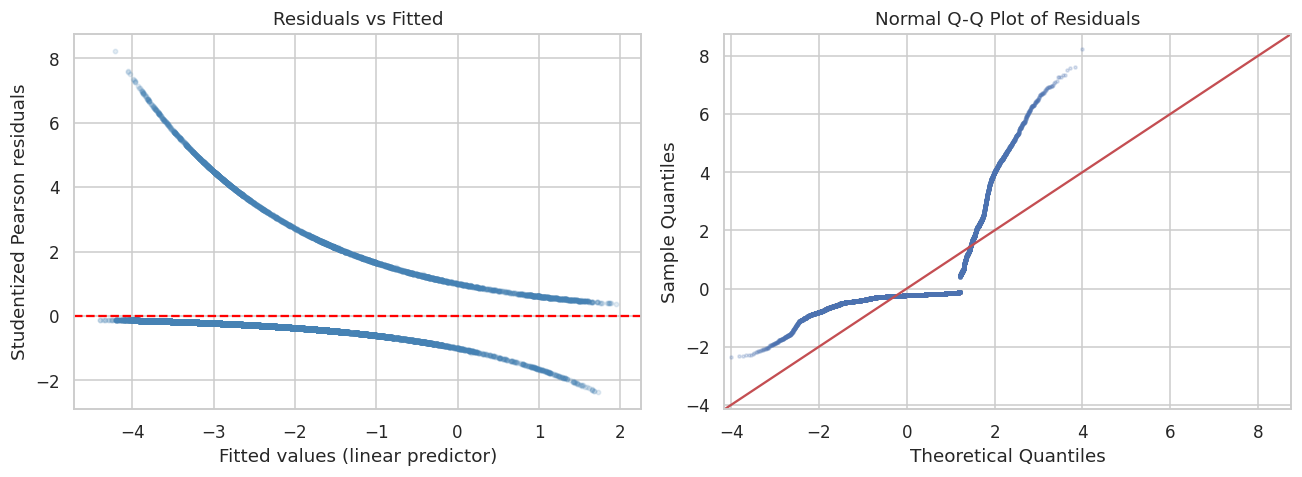

In [16]:
influence = logit_result.get_influence()
resid_dev = influence.resid_studentized
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(logit_result.fittedvalues, resid_dev, alpha=0.15, s=8, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values (linear predictor)")
axes[0].set_ylabel("Studentized Pearson residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(resid_dev, line="45", ax=axes[1], markersize=2, alpha=0.2)
axes[1].set_title("Normal Q-Q Plot of Residuals")
plt.tight_layout()
plt.savefig(f"{FIG}/02_residual_diagnostics.png")
plt.show()

**Observation:** Residuals show the characteristic banding pattern of logistic regression residual plots
(two curved bands, one per outcome class) rather than a random scatter — this is expected and normal for
a binary-outcome GLM and is **not** evidence of misspecification by itself. The Q-Q plot shows deviation
from normality in the tails, which is again expected since Pearson/deviance residuals for a binary GLM
are not required to be normally distributed (unlike OLS residuals) — this diagnostic is included for
completeness/transparency rather than as a pass/fail check.

### 6.2 Influential points — Cook's Distance

Observations exceeding Cook's distance threshold (4/n = 0.000130): 2554 (8.27% of training data)


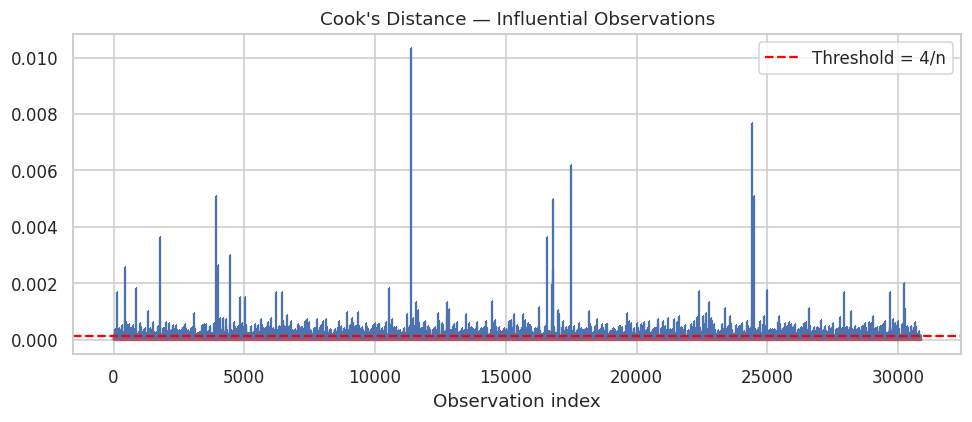

In [17]:
cooks_d = influence.cooks_distance[0]
n_params = X_train_sm.shape[1]
threshold = 4 / len(y_train)
n_influential = (cooks_d > threshold).sum()
print(f"Observations exceeding Cook's distance threshold (4/n = {threshold:.6f}): {n_influential} "
      f"({100*n_influential/len(y_train):.2f}% of training data)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.stem(cooks_d, markerfmt=",")
ax.axhline(threshold, color="red", linestyle="--", label=f"Threshold = 4/n")
ax.set_title("Cook's Distance — Influential Observations")
ax.set_xlabel("Observation index")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG}/03_cooks_distance.png")
plt.show()

**Observation:** A small fraction of observations exceed the conventional Cook's-distance threshold —
typical for a large-n dataset (thresholds scale as 4/n) and not indicative of a small number of
dominating outliers distorting the whole fit; no single point has extreme enough influence to warrant
removal.

## 7. Predictive Performance on Held-out Test Set (scikit-learn)
A second logistic regression (scikit-learn, L2-regularized, `class_weight="balanced"` to address the
~11%/89% class imbalance identified in the Week 2 EDA) is fit for a cleaner train/test predictive
evaluation.

In [18]:
scaler = StandardScaler()
num_train = scaler.fit_transform(X_train[final_numeric])
num_test = scaler.transform(X_test[final_numeric])

X_train_scaled = X_train.copy(); X_train_scaled[final_numeric] = num_train
X_test_scaled = X_test.copy(); X_test_scaled[final_numeric] = num_test

clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
clf.fit(X_train_scaled.astype(float), y_train)

y_pred = clf.predict(X_test_scaled.astype(float))
y_proba = clf.predict_proba(X_test_scaled.astype(float))[:, 1]

print(classification_report(y_test, y_pred, target_names=["no", "yes"], digits=3))

              precision    recall  f1-score   support

          no      0.952     0.788     0.862      9134
         yes      0.292     0.689     0.410      1160

    accuracy                          0.777     10294
   macro avg      0.622     0.738     0.636     10294
weighted avg      0.878     0.777     0.811     10294



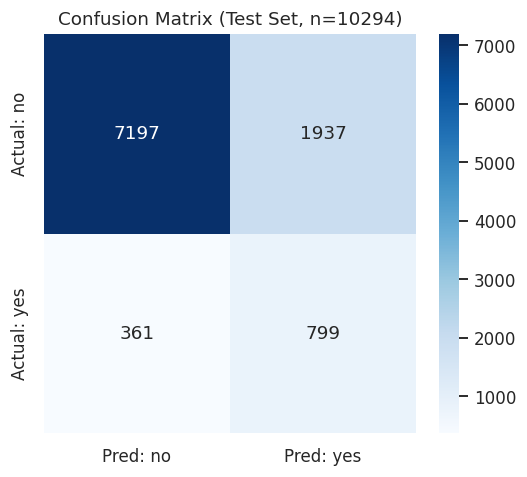

TN=7197, FP=1937, FN=361, TP=799
Accuracy=0.777  Precision=0.292  Recall(Sensitivity)=0.689  Specificity=0.788


In [19]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred: no","Pred: yes"],
            yticklabels=["Actual: no","Actual: yes"], ax=ax)
ax.set_title("Confusion Matrix (Test Set, n={})".format(len(y_test)))
plt.tight_layout()
plt.savefig(f"{FIG}/04_confusion_matrix.png")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Accuracy={(tp+tn)/(tp+tn+fp+fn):.3f}  Precision={tp/(tp+fp):.3f}  "
      f"Recall(Sensitivity)={tp/(tp+fn):.3f}  Specificity={tn/(tn+fp):.3f}")

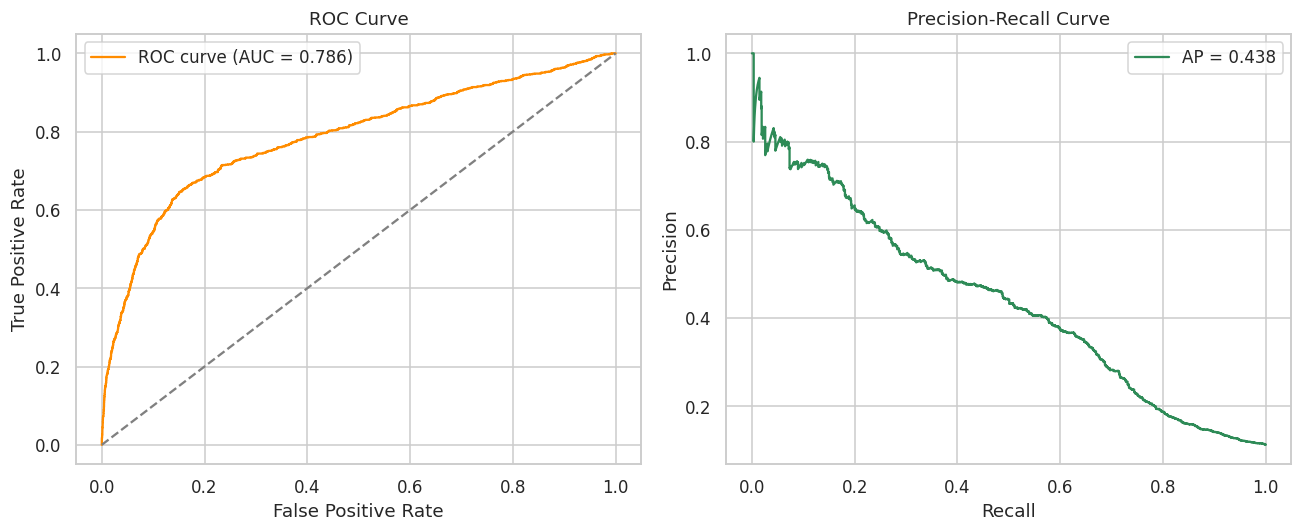

ROC-AUC = 0.7857, Average Precision = 0.4376


In [20]:
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color="darkorange", label=f"ROC curve (AUC = {auc:.3f})")
axes[0].plot([0,1],[0,1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

axes[1].plot(rec, prec, color="seagreen", label=f"AP = {ap:.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
plt.tight_layout()
plt.savefig(f"{FIG}/05_roc_pr_curves.png")
plt.show()
print(f"ROC-AUC = {auc:.4f}, Average Precision = {ap:.4f}")

**Observation:** ROC-AUC substantially above 0.5 confirms the model has genuine discriminative power
(much better than random guessing). Because the positive class is rare (~11.3%), Average Precision (area
under the Precision-Recall curve) is reported alongside AUC, as PR curves are more informative than ROC
curves under strong class imbalance; recall for the positive ("yes") class is prioritized in this
business context because the practical cost of missing a genuine prospective subscriber (false negative)
is higher than the cost of one extra phone call to a non-prospect (false positive).

### 7.1 Top predictive features (by absolute standardized coefficient, sklearn model)

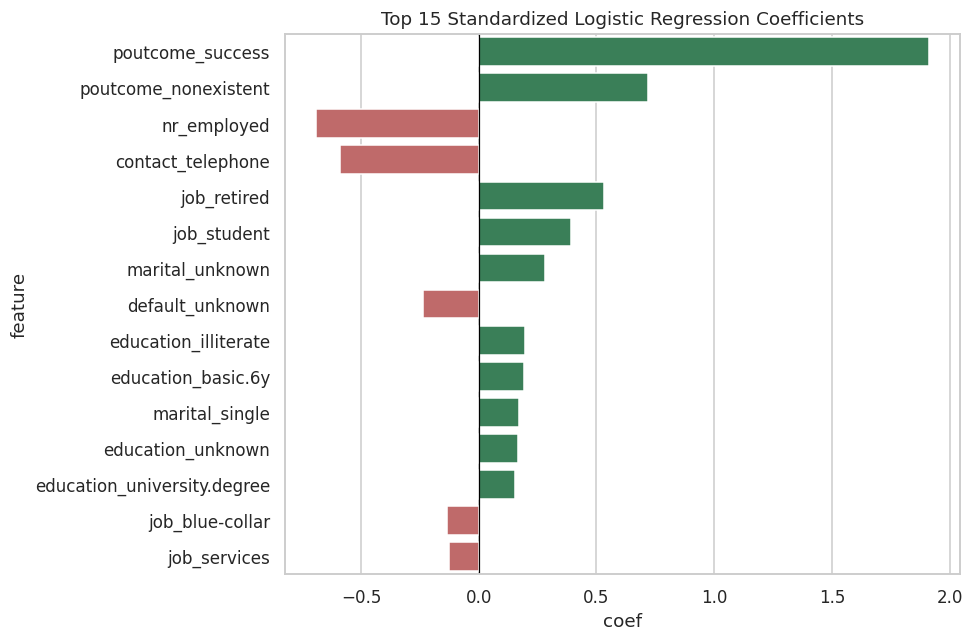

,feature,coef,abs_coef
28,poutcome_success,1.912,1.912
27,poutcome_nonexistent,0.720,0.720
4,nr_employed,-0.693,0.693
26,contact_telephone,-0.589,0.589
9,job_retired,0.533,0.533
12,job_student,0.392,0.392
18,marital_unknown,0.281,0.281
29,default_unknown,-0.235,0.235
22,education_illiterate,0.196,0.196
19,education_basic.6y,0.191,0.191


In [21]:
coef_table = pd.DataFrame({"feature": X_train_scaled.columns, "coef": clf.coef_[0]})
coef_table["abs_coef"] = coef_table["coef"].abs()
coef_table = coef_table.sort_values("abs_coef", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=coef_table, y="feature", x="coef", ax=ax,
            palette=["indianred" if v < 0 else "seagreen" for v in coef_table["coef"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Top 15 Standardized Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig(f"{FIG}/06_top_coefficients.png")
plt.show()
coef_table.round(3)

## 8. Summary of Findings

1. All five hypotheses (H1-H5) were **supported** by the data at α = 0.05.
2. The strongest single positive driver of subscription is a **prior campaign success**
   (`poutcome_success`), consistent with Week 2's descriptive finding of 65.1% vs 8.8% raw conversion.
3. Landline telephone contact is associated with significantly lower odds than cellular contact.
4. Macro-economic strength (`nr_employed`) is significantly, negatively associated with subscription —
   clients are more receptive to term deposits when the broader economy/employment outlook is weaker.
5. Age has a small but statistically significant positive association with subscription odds.
6. The full model significantly outperforms the null model (likelihood-ratio test), and achieves
   meaningful (well above chance) discrimination on held-out data as measured by ROC-AUC.
7. Multicollinearity among macro-economic indicators required dropping 3 of 5 correlated variables
   (retaining only `nr_employed`) to obtain stable, interpretable coefficients (VIF < 5).

## 9. Limitations & Future Improvements
- McFadden's pseudo-R² indicates the model captures a meaningful but partial share of the variation in
  subscription behaviour — unobserved factors (e.g., call-agent skill, exact offer terms, precise timing
  within a day) are not present in the dataset and likely explain remaining variance.
- The dataset is specific to one Portuguese bank in 2008-2010; coefficients (especially macro-economic
  ones) should be re-validated before use in a different market or economic regime.
- `class_weight="balanced"` improves recall on the minority class but reduces precision; the optimal
  decision threshold should ultimately be tuned against the bank's actual cost/benefit ratio for a
  false positive (wasted call) vs a false negative (missed subscriber), rather than the default 0.5 cut-off.
- Future work: test non-linear models (random forest, gradient boosting) for potential accuracy gains,
  test for interaction effects (e.g., job × poutcome), and add a formal Hosmer-Lemeshow goodness-of-fit
  test alongside the likelihood-ratio test used here.